In [9]:
import keras
import tensorflow as tf
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.layers import Conv2D, MaxPooling2D, GlobalMaxPooling2D, BatchNormalization
from sklearn.metrics import confusion_matrix
import seaborn as sns

## setting constant

In [10]:
batch_size = 32
num_class = 10


In [36]:
# The data , shuffled and split between train and test sets:
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [37]:
X_train.shape

(50000, 32, 32, 3)

In [38]:
y_train.shape

(50000, 1)

In [39]:
# convert class vectors to binary class metrics
y_train = keras.utils.to_categorical(y_train, num_class)
y_test = keras.utils.to_categorical(y_test, num_class)

In [40]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(50000, 10))

##showing images

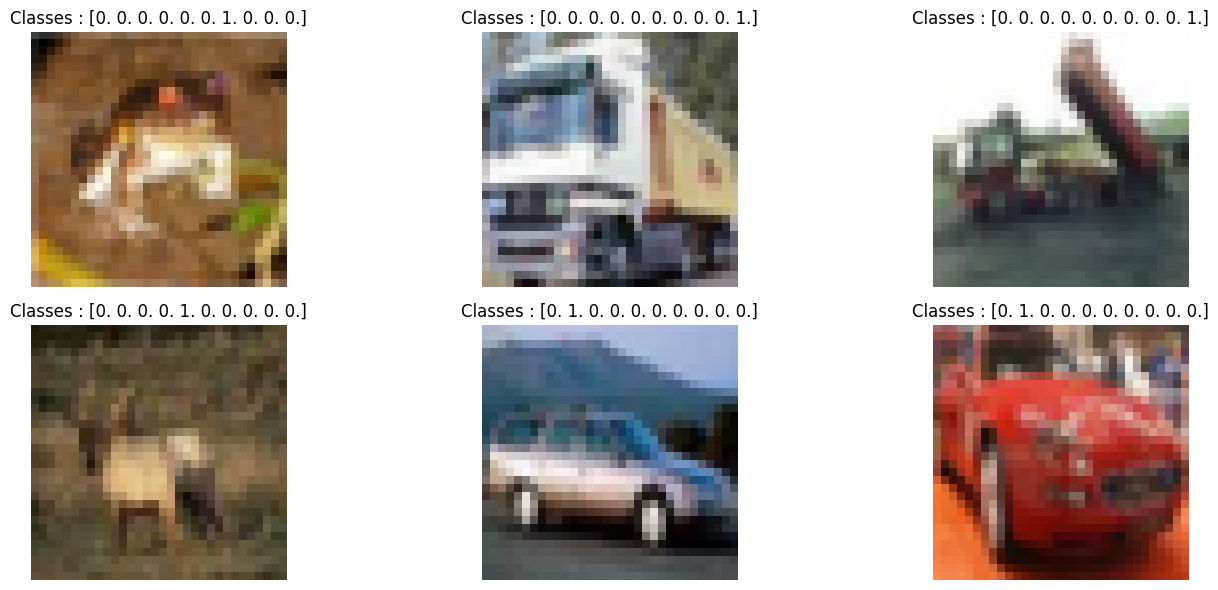

In [44]:
import matplotlib.pyplot as plt
fig , axes = plt.subplots(2, 3, figsize=(15,6))

axes = axes.flatten()
for i in range(6):
    axes[i].imshow(X_train[i])
    axes[i].axis("off")
    axes[i].set_title(f"Classes : {y_train[i]}")
plt.tight_layout()
plt.show()

## Feature Scaling

In [46]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train /=255
X_test /=255

In [47]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

## Model Architecture

In [52]:
X_train.shape[1:]

(32, 32, 3)

In [58]:
model = Sequential()

#layer 1 
model.add(Conv2D(32 ,(3,3), kernel_initializer='random_uniform', input_shape=X_train.shape[1:]))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(32 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(48 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(48 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(48 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(64 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(64 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(128 ,(3,3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(GlobalMaxPooling2D())
model.add(Dropout(0.25))

model.add(Dense(num_class))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 26, 26, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 22, 22, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 22, 22, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 22, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 20, 20, 64)     │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 207,226 (809.48 KB)

 Trainable params: 206,298 (805.85 KB)

 Non-trainable params: 928 (3.62 KB)

In [ ]:
opt = keras.optimizers.Adamax(learning_rate=0.001)
model.compile(loss="categorical_crossentropy",optimizer=opt, metrics=['accuracy'])

In [60]:
history = model.fit(X_train,y_train, 
                    batch_size=500,
                    epochs=10,
                    validation_data=(X_test, y_test),
                    shuffle=True)

Epoch 1/10
  4/100 ━━━━━━━━━━━━━━━━━━━━ 15:22 10s/step - accuracy: 0.1171 - loss: 6.5562

KeyboardInterrupt: 